### Importing Dependencies

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [24]:
import sys
import os

# Add project root (one level up) to path
sys.path.append(os.path.abspath('..'))
from scripts import my_utils


#### Load Data

In [25]:
#loading the data
df = pd.read_csv('../data/tanzania.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


#### Data Parsing

In [26]:
#Add a country column with the country name
df['country'] = 'Tanzania'
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania


In [27]:
#Convert the YEAR and DOY columns to a proper datetime format
df['date'] = pd.to_datetime(df['YEAR']*1000 + df['DOY'], format="%Y%j")
df['month'] = df['date'].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country,date,month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


### Summary Statistics & Missing-Value Report

In [28]:
#Replace the -999 values with NaN
df.replace(-999, np.nan)
df.describe()
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country,date,month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


In [29]:
# Check for duplicates
df.duplicated().sum()

0

In [30]:
#Numeric columns describe
df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']].describe()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000
mean,26.802422,29.163493,25.03813,3.740256,77.128038,4.105370,5.189248
std,1.325388,1.371155,1.53544,8.003947,5.070501,1.059803,1.215018
min,22.680000,25.410000,20.03000,0.000000,60.060000,1.120000,1.550000
25%,25.670000,28.090000,23.71000,0.110000,73.167500,3.410000,4.377500
50%,26.990000,29.080000,25.37500,0.640000,76.585000,4.190000,5.250000
75%,27.900000,30.170000,26.31000,3.790000,81.100000,4.830000,5.980000
max,29.970000,33.930000,28.01000,122.650000,91.100000,8.400000,11.740000


In [31]:
# Compute the percentage of missing values in each column
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
country        0
date           0
month          0
dtype: int64

#### Outlier Detection & Basic Cleaning

In [32]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

In [33]:
z_scores = np.abs(stats.zscore(df[cols_to_check]))
outliers_mask = (z_scores > 3).any(axis=1)
print(f"\n Rows flagged as outliers: {outliers_mask.sum()}")


 Rows flagged as outliers: 97


In [34]:
# Remove outliers
df_clean = df[~outliers_mask].copy()

In [35]:
print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(df_clean)}")
print(f"Remaining negatives: {(df_clean[cols_to_check] < 0).sum().sum()}")

Original rows: 4108
Cleaned rows: 4011
Remaining negatives: 0


#### Handle Missing Data


In [36]:
df_filtered = df[df.isna().mean(axis=1) <= 0.3]
print(f"Original rows: {len(df)}")
print(f"Filtered rows: {len(df_filtered)}")


Original rows: 4108
Filtered rows: 4108


## Export Data

In [37]:
df.to_csv('../data/tanzania_clean.csv', index=False)

### Time Series Analysis

<Axes: title={'center': 'Temperature vs date in Tanzaia'}, xlabel='Date', ylabel='Temprature(C)'>

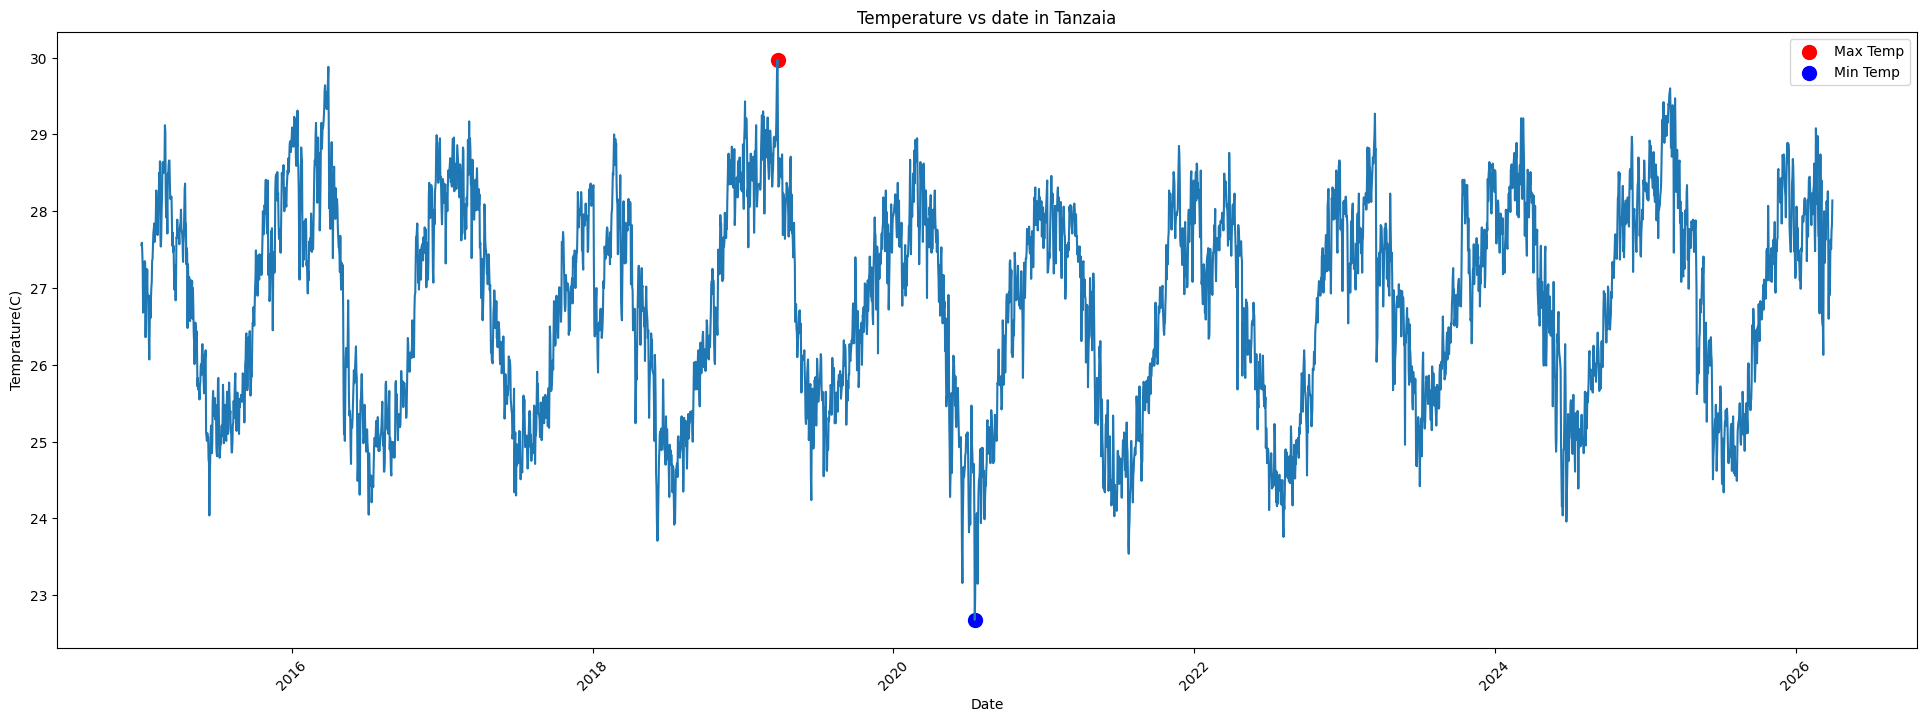

In [38]:
my_utils.plot_temperature(df, date_col='date', temp_col='T2M',
					 title='Temperature vs date in Tanzaia',
					 ylabel='Temprature(C)',
					 figsize=(24, 8),
					 annotate=True, ax=None)

### Correlation & Relationship Analysis

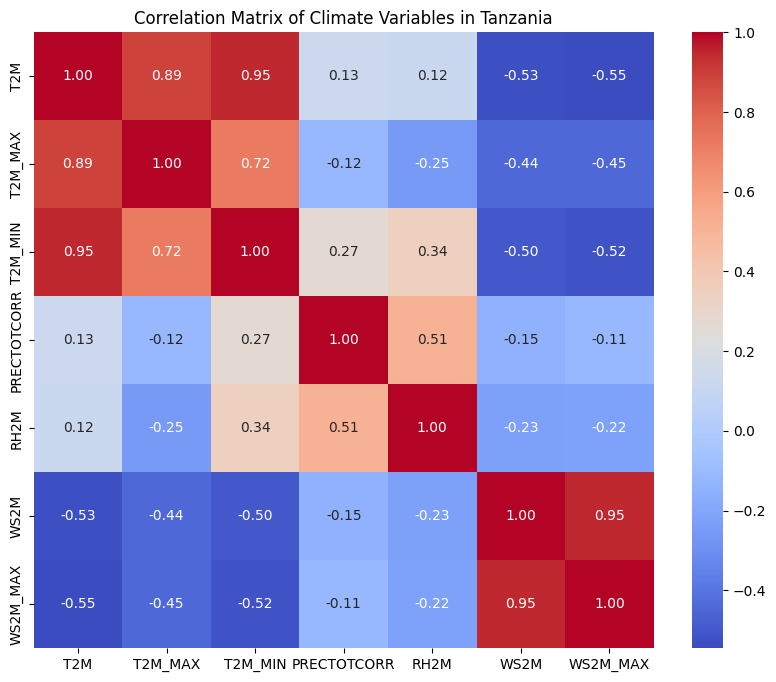

In [39]:
# Heatmap of correlations across all numeric columns
corr_matrix = df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Climate Variables in Tanzania')
plt.show()

### Scatter Plots 

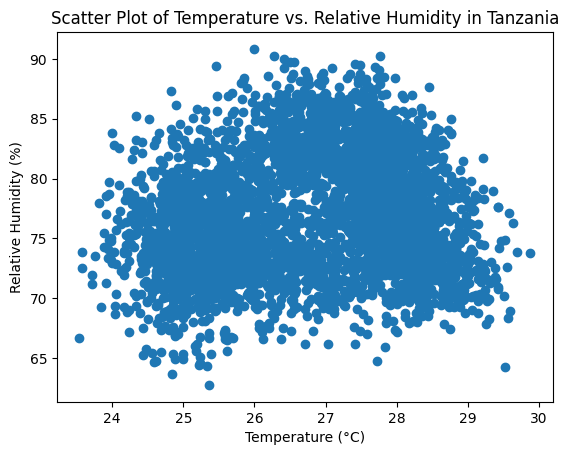

In [40]:
#scatter plot T2M vs RH2M

plt.scatter(df_clean['T2M'], df_clean['RH2M'])
plt.title('Scatter Plot of Temperature vs. Relative Humidity in Tanzania')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()

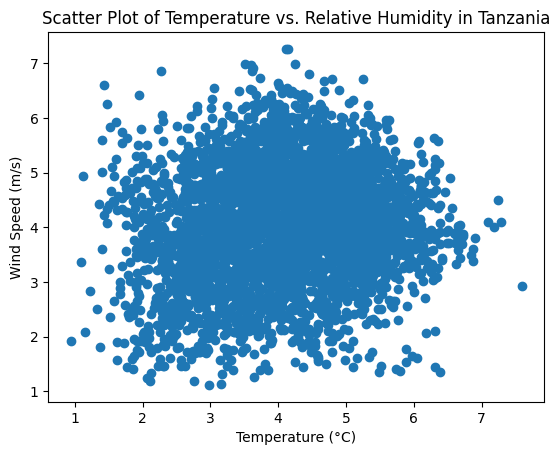

In [41]:
#scatter plot T2M_RANGE vs WS2M

plt.scatter(df_clean['T2M_RANGE'], df_clean['WS2M'])
plt.title('Scatter Plot of Temperature vs. Relative Humidity in Tanzania')
plt.xlabel('Temperature (°C)')
plt.ylabel('Wind Speed (m/s)')
plt.show()

### Distribution Analysis

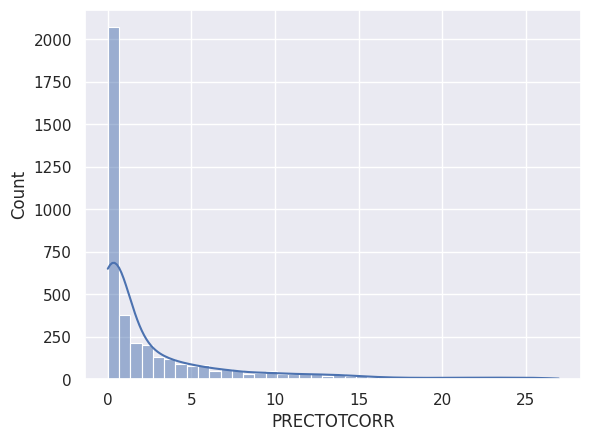

In [42]:
sns.set_theme(style="darkgrid")
sns.histplot(df_clean['PRECTOTCORR'], bins=40, kde=True)

plt.show()

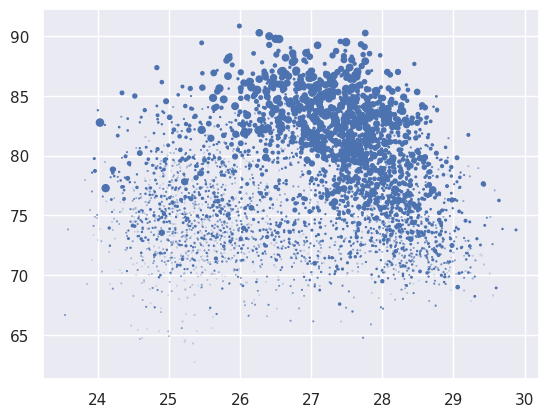

In [43]:
plt.scatter(x='T2M', y='RH2M', data=df_clean, s='PRECTOTCORR')